# Interpretación de Ventas en Tienda (Retail)

Auditar las ventas nos permite entender qué días o bajo qué condiciones (promociones, clima, festivos) el stock se agota más rápido.

### 🛠️ Ajuste de Seguridad:
Al igual que en el bloque anterior, el código ahora cuenta el número de filas disponibles antes de intentar el muestreo, evitando el error de "index out of bounds".

✅ Recursos de Tienda cargados con éxito.
⏳ Generando impacto SHAP para 5 registros de ventas...


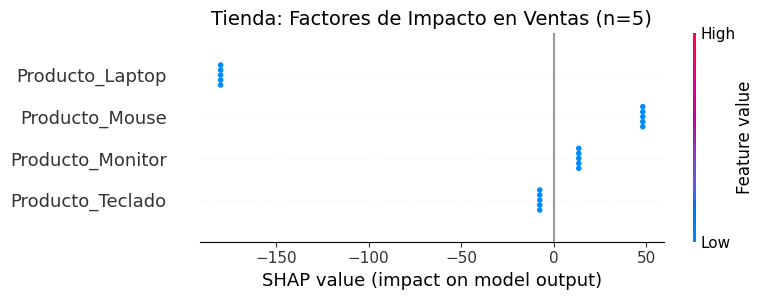

✅ ¡Auditoría de tienda completada y visualizada!


In [4]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. CARGA DE RECURSOS (Rutas corregidas tras diagnóstico)
path_mod = '../../../models/modelo_tienda_optimizado_v2.pkl'
path_dat = '../../../data/processed/tienda_limpia.csv' # <--- Corregido: 'tienda_limpia.csv'

try:
    modelo_tienda = joblib.load(path_mod)
    df_tienda = pd.read_csv(path_dat)
    print("✅ Recursos de Tienda cargados con éxito.")
except Exception as e:
    print(f"❌ Error persistente: {e}. Verifica si el modelo .pkl existe.")

# 2. ALINEACIÓN Y MUESTREO
if 'df_tienda' in locals():
    cols_t = modelo_tienda.feature_names_in_
    X_tienda_all = df_tienda.reindex(columns=cols_t, fill_value=0)

    # Ajustamos la muestra según disponibilidad
    n_tienda = min(len(X_tienda_all), 300)
    X_tienda = X_tienda_all.sample(n=n_tienda, random_state=42)

    # 3. CÁLCULO SHAP
    print(f"⏳ Generando impacto SHAP para {n_tienda} registros de ventas...")
    explainer_t = shap.TreeExplainer(modelo_tienda)
    shap_values_t = explainer_t.shap_values(X_tienda, check_additivity=False)

    # 4. RENDERIZADO
    plt.close('all')
    plt.figure(figsize=(10, 6))
    
    # Manejo de dimensiones para Regresión
    v_plot = shap_values_t[0] if isinstance(shap_values_t, list) else shap_values_t
    
    shap.summary_plot(v_plot, X_tienda, show=False)
    plt.title(f"Tienda: Factores de Impacto en Ventas (n={n_tienda})", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("✅ ¡Auditoría de tienda completada y visualizada!")